In [1]:
import numpy as np
import tifffile
import matplotlib.pyplot as plt
from roifile import roiread
from matplotlib.path import Path
from numpy.lib.stride_tricks import sliding_window_view

Astrocytes: Stack (T,H,W) (226, 512, 512) | Masks (N,H,W): (13, 512, 512)


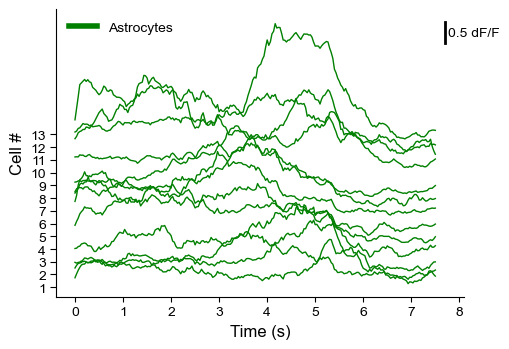

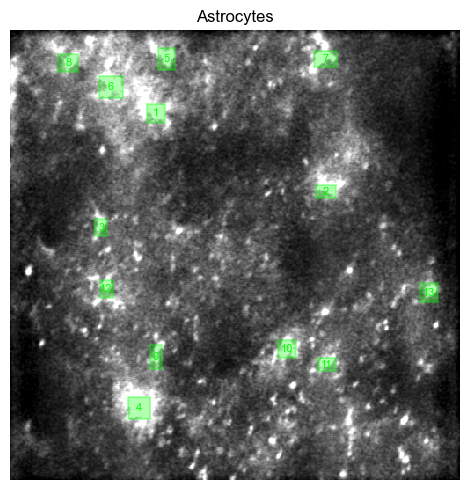

In [26]:
fs = 29.989  # sampling rate (Hz)
seconds = 7.536  # seconds to display
spacing = 0.3  # vertical spacing between traces (also used as dF/F scale bar)
smooth_k = 7  # moving-average window (frames) for display only
win_s = 4  # rolling baseline window (seconds)
percentile = 10  # rolling baseline percentile
ASCENDING = True  # sort by amplitude: False=largest→smallest, True=smallest→largest
label_every = 1  # show every Nth numeric label on y-axis (1=show all)
save_path = 'plot_smallerROIS.svg'  # set to None to skip saving

def load_mean_image(tif_path):
    """Read TIF stack and return mean image (H, W)."""
    stack = to_THW(tifffile.imread(tif_path))
    mean_img = stack.mean(axis=0)
    return mean_img, stack.shape  # ((H, W), (T,H,W))


def load_rois(roi_path):
    """Return list of ROI objects (always a list)."""
    rois = roiread(roi_path)
    if not isinstance(rois, (list, tuple)):
        rois = [rois]
    return rois


def plot_masks_over_mean(tif_path, roi_path, edgecolor="lime", fill=False,
                         fill_alpha=0.15, linewidth=1.5, label=True,
                         save_as=None, title=None):
    """
    Overlay ROI outlines on the mean image.
    """
    mean_img, (_, H, W) = load_mean_image(tif_path)
    rois = load_rois(roi_path)

    # display mean image with robust contrast
    vmin = np.percentile(mean_img, 2)
    vmax = np.percentile(mean_img, 98)

    fig, ax = plt.subplots(figsize=(5.0, 5.0))
    ax.imshow(mean_img, cmap="gray", vmin=vmin, vmax=vmax, interpolation="nearest")
    ax.set_xlim(0, W)
    ax.set_ylim(H, 0)  # y-down to match ImageJ coordinates

    # draw each ROI
    for i, r in enumerate(rois, start=1):
        xy = r.coordinates()
        if xy is None or len(xy) == 0:
            continue
        # close polygon for clean outlines/fills
        if not np.array_equal(xy[0], xy[-1]):
            xy = np.vstack([xy, xy[0]])

        if fill:
            ax.fill(xy[:, 0], xy[:, 1], edgecolor=edgecolor, facecolor=edgecolor,
                    lw=linewidth, alpha=fill_alpha)
        else:
            ax.plot(xy[:, 0], xy[:, 1], color=edgecolor, lw=linewidth)

        if label:
            cx, cy = xy[:-1, 0].mean(), xy[:-1, 1].mean()
            ax.text(cx, cy, str(i), color=edgecolor, fontsize=8,
                    ha="center", va="center")

    ax.set_title(title or "ROI overlays on mean image")
    ax.axis("off")
    plt.tight_layout()

    if save_as:
        import matplotlib as mpl
        mpl.rcParams['svg.fonttype'] = 'none'
        fig.savefig(save_as, bbox_inches="tight", transparent=True)

    return fig, ax


def to_THW(arr):
    """Return stack as (T, H, W)"""
    if arr.ndim != 3:
        raise ValueError(f"Expected 3D stack, got {arr.shape}")
    H, W = None, None

    # Identify the time axis as the smallest dimension if it is clearly smaller
    sizes = np.array(arr.shape)
    t_ax = int(np.argmin(sizes))
    spatial = np.delete(sizes, t_ax)
    # require that time is at least ~2× smaller than the larger spatial dim
    if sizes[t_ax] >= 0.5 * spatial.max():
        # ambiguous: assume tifffile “(T, H, W)” default
        t_ax = 0

    out = np.moveaxis(arr, t_ax, 0)  # (T, ?, ?)
    T, A, B = out.shape
    # Make sure the two trailing dims look like an image (H, W), not (W, T) etc.
    # Put the larger of the two first: (H, W)
    if A < B:
        out = np.transpose(out, (0, 2, 1))
    return out



def rois_to_masks(roi_path, shape_hw):
    """
    ImageJ ROI zip -> (N, H, W) boolean masks and a list of names.
    """
    rois = roiread(roi_path)
    if not isinstance(rois, (list, tuple)):
        rois = [rois]
    H, W = shape_hw
    yy, xx = np.mgrid[0:H, 0:W]
    pts = np.column_stack((xx.ravel(), yy.ravel()))
    masks, names = [], []
    for i, r in enumerate(rois):
        xy = r.coordinates()
        if xy is None or len(xy) == 0:
            continue
        m = Path(xy).contains_points(pts).reshape(H, W)
        masks.append(m)
        names.append(getattr(r, "name", f"ROI_{i + 1}"))
    masks = np.stack(masks, 0) if masks else np.zeros((0, H, W), bool)
    return masks, names


def extract_traces(stack_THW, masks_NHW):
    """Mean fluorescence per ROI per frame. Returns (T, N)."""
    T, H, W = stack_THW.shape
    N = masks_NHW.shape[0]
    flat = stack_THW.reshape(T, H * W)
    out = np.empty((T, N), float)
    for i in range(N):
        idx = np.flatnonzero(masks_NHW[i].ravel())
        out[:, i] = flat[:, idx].mean(1)
    return out


def dff_rolling_percentile(F, fs=20.0, win_s=8.0, p=10):
    """
    ΔF/F with rolling p-th percentile baseline (robust to transients/drift).
    F: (T, N)
    """
    T, _ = F.shape
    win = int(max(3, round(win_s * fs)))
    if win % 2 == 0:
        win += 1
    pad = win // 2
    Fpad = np.pad(F, ((pad, pad), (0, 0)), mode="edge")
    Fw = sliding_window_view(Fpad, (win, 1))[:, :, 0, :]  # (T, win, N)
    F0 = np.percentile(Fw, p, axis=1)  # (T, N)
    return (F - F0) / np.clip(F0, 1e-9, None)


def smooth_for_plot(dff, k=5):
    """Centered moving-average smoothing for display."""
    if k % 2 == 0:
        k += 1
    kern = np.ones(k) / k
    return np.apply_along_axis(lambda x: np.convolve(x, kern, mode="same"), 0, dff)


def plot_traces_numeric_labels(dff, fs=20.0, seconds=30.0, spacing=0.7,
                               lw=1.0, color="black", label_every=2,
                               save_path=None):
    """
    Plot traces stacked by 'spacing', with numeric y-axis labels (1..N).
    Only every `label_every` label is shown to reduce clutter.
    """
    T, N = dff.shape
    T_plot = min(T, int(round(seconds * fs)))
    t = np.arange(T_plot) / fs

    fig, ax = plt.subplots(figsize=(3, 2))
    for i in range(N):
        ax.plot(t, dff[:T_plot, i] + i * spacing, color=color, lw=lw)

    # y ticks / numeric labels
    yticks = [i * spacing for i in range(N)]
    ax.set_yticks(yticks)
    ylabels = [str(i + 1) if (i % label_every == 0) else "" for i in range(N)]
    ax.set_yticklabels(ylabels)

    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Cell #")
    ax.tick_params(axis="y", which="major", length=4, labelsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # dF/F scale bar of height=spacing
    x0, x1 = ax.get_xlim()
    y0, y1 = ax.get_ylim()
    x_pad = 0.02 * (x1 - x0)
    y_pad = 0.04 * (y1 - y0)
    xb = x1 - x_pad
    yb = y1 - y_pad
    ax.plot([xb, xb], [yb - spacing, yb], color="k", lw=2)
    ax.text(xb + x_pad * 0.3, yb - spacing / 2, f"{spacing} dF/F",
            va="center", ha="left")

    plt.tight_layout()
    if save_path:
        import matplotlib as mpl
        mpl.rcParams['svg.fonttype'] = 'none'  # keep text as text in SVG
        fig.savefig(save_path, format=save_path.split('.')[-1],
                    bbox_inches="tight", transparent=True)
    return fig, ax


# ---------- Pipeline: two datasets ----------
if __name__ == "__main__":
    datasets = [
        {
            "tif": "/Users/suthardr/Desktop/clipped_stack_rep.tif",
            "roi": "/Users/suthardr/Desktop/RoiSet_Smaller.zip",
            "color": "green",
            "label": "Astrocytes",
        },
        # {
        #     "tif": "/Users/suthardr/Desktop/20250708_FC_dualcolorpilot_fullsession_621N/channel2_clean_part1.tif",
        #     "roi": "/Users/suthardr/Desktop/20250708_FC_dualcolorpilot_fullsession_621N/RoiSet_AVG_channel2_clean_part1.zip",
        #     "color": "red",
        #     "label": "Neurons",
        # },
    ]

    # --- Formatting ---
    tick_step = 1  # y-axis tick every 3 cells
    scale_amp = 0.5  # dF/F scale bar amplitude
    label_fs = 12  # axis labels font size
    tick_fs = 10  # tick label font size
    legend_fs = 10  # legend font size

    # Set global font to Arial
    import matplotlib as mpl

    mpl.rcParams['font.family'] = 'Arial'
    mpl.rcParams['svg.fonttype'] = 'none'

    # ---- process both datasets ----
    traces_list, colors, labels, Ns = [], [], [], []
    for d in datasets:
        stack = to_THW(tifffile.imread(d["tif"]))
        masks, _ = rois_to_masks(d["roi"], stack.shape[1:])
        print(f"{d['label']}: Stack (T,H,W) {stack.shape} | Masks (N,H,W): {masks.shape}")

        F = extract_traces(stack, masks)
        dff = dff_rolling_percentile(F, fs=fs, win_s=win_s, p=percentile)
        dff = smooth_for_plot(dff, k=smooth_k)

        amp = np.ptp(dff, axis=0)
        order = np.argsort(amp) if ASCENDING else np.argsort(-amp)
        dff_sorted = dff[:, order]

        traces_list.append(dff_sorted)
        colors.append(d["color"])
        labels.append(d["label"])
        Ns.append(dff_sorted.shape[1])

    # ---- build time vector ----
    T_plot = min([tr.shape[0] for tr in traces_list])
    T_plot = min(T_plot, int(round(seconds * fs)))
    t = np.arange(T_plot) / fs

    fig, ax = plt.subplots(figsize=(5.2, 3.6))

    # ---- sequential plotting ----
    base_idx = 0
    legend_handles = []
    for traces, color, lab, N in zip(traces_list, colors, labels, Ns):
        for i in range(N):
            y_offset = (base_idx + i) * spacing
            ax.plot(t, traces[:T_plot, i] + y_offset, color=color, lw=1.0)
        h, = ax.plot([], [], color=color, lw=4, label=lab)
        legend_handles.append(h)
        base_idx += N

    Ntotal = sum(Ns)

    # ---- y-axis ticks ----
    tick_idx = list(range(0, Ntotal, max(1, tick_step)))
    if tick_idx[-1] != Ntotal - 1:  # ensure last ROI is labeled
        tick_idx.append(Ntotal - 1)
    yticks = [i * spacing for i in tick_idx]
    ylabels = [str(i + 1) for i in tick_idx]
    ax.set_yticks(yticks)
    ax.set_yticklabels(ylabels, fontsize=tick_fs)

    # ---- axis labels ----
    ax.set_xlabel("Time (s)", fontsize=label_fs)
    ax.set_ylabel("Cell #", fontsize=label_fs)
    ax.tick_params(axis="x", labelsize=tick_fs)
    ax.tick_params(axis="y", length=4)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # ---- TRUE dF/F scale bar ----
    x0, x1 = ax.get_xlim()
    y0, y1 = ax.get_ylim()
    x_pad = 0.02 * (x1 - x0)
    y_pad = 0.04 * (y1 - y0)
    xb = x1 - x_pad
    yb = y1 - y_pad
    ax.plot([xb, xb], [yb - scale_amp, yb], color="k", lw=2)
    ax.text(xb + x_pad * 0.35, yb - scale_amp / 2, f"{scale_amp} dF/F",
            va="center", ha="left", fontsize=tick_fs)

    # ---- legend ----
    ax.legend(handles=legend_handles, frameon=False, fontsize=legend_fs, loc="upper left")

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, format=save_path.split('.')[-1],
                    bbox_inches="tight", transparent=True)
    plt.show()

# Quick QC overlay for the first dataset
plot_masks_over_mean(
    tif_path=datasets[0]["tif"],
    roi_path=datasets[0]["roi"],
    edgecolor="lime",
    fill=True,  # set True if you want translucent fills
    fill_alpha=0.3,
    linewidth=1.5,
    label=True,
    save_as="mean_with_rois_smaller.svg",  # or None
    title=datasets[0]["label"]
)
plt.show()
